# Heart Rate Interval Segmentation with XGBoost

This notebook implements an XGBoost-based classifier to automatically detect workout interval boundaries from heart rate time series data.

**How it works:**
1. **Feature Engineering**: Extracts 30 statistical, temporal, and derivative features from heart rate data (e.g., rolling statistics, rate of change, normalized values, look-ahead/look-behind features) per session. The features are based on each session.

2. **Training Approach**: The model is trained on **multiple workout sessions combined** (not per-session). All training sessions are pooled together into a single dataset, allowing the model to learn generalizable patterns across different athletes and workout types.

3. **Classification**: XGBoost learns to classify each time point as either a boundary (interval transition) or non-boundary by identifying characteristic heart rate patterns around transitions.

4. **Post-Processing**: Applies peak detection to the predicted probability curve, constraining results to match the expected number of intervals per session.

**Key Features:**
- Uses top 30 features identified through prior feature importance analysis
- Handles class imbalance (boundaries are rare) via `scale_pos_weight` parameter
- Evaluates with time tolerance (±10 seconds) to account for natural variability in boundary timing
- F-beta metric (2:1 recall bias) prioritizes finding all boundaries over precision

## 1. Install Dependencies (Run Once)

In [36]:
#!pip install numpy pandas scikit-learn xgboost scipy matplotlib seaborn --break-system-packages

## 2. Imports

In [37]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Reproducibility
RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # For GPU determinism

print("✓ Imports complete")

✓ Imports complete


## 3. Configuration

In [38]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    # These define the time windows used to calculate statistical features from HR data
    short_window: int = 20
    medium_window: int = 40
    long_window: int = 80
    
    # Model
    model_type: str = "xgboost"
    xgb_max_depth: int = 8 # Maximum depth of each decision tree (higher = more complex, risk of overfitting)
    xgb_n_estimators: int = 300 # Number of boosting rounds/trees to build
    xgb_learning_rate: float = 0.05 # Step size for each tree's contribution
    xgb_scale_pos_weight: float = 50.0 # Weight multiplier for positive class (boundaries) to handle class imbalance
    
    # Post-processing
    peak_distance: int = 30 # Minimum time between detected interval boundaries
    peak_prominence: float = 0.1 # Minimum prominence of probability peaks to be considered a boundary
    smooth_sigma: float = 5.0 # Smooths the probability curve to reduce noise before peak detection

CONFIG = Config()
print(f"✓ Configuration set (model: {CONFIG.model_type})")

✓ Configuration set (model: xgboost)


## 4. Your Data Configuration

Inkludiert nun 93 workout sessions.

Bei den neuen SpecialBikes Sessions waren auch zwei Rudereinheiten dabei.
Grundsätzlich ist zumindest die "Resting HR" in den Fit Files vorhanden. Aber nachdem das Model die Zones zurzeit nicht verwendet, sind sie nicht inkludiert.

In [39]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialRowing": {
    "sport": "rowing",
    "ftp": None,
    "fit_dir": None,
    "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
    "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## 5. Feature Engineering Functions

Feature engineering: Extract 30 most important statistical, temporal, and derivative features from heart rate time series data for a single workout session.
These 30 features were pre-selected based on feature importance scores from prior model training.

In [40]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:

    # Initialize empty DataFrame to store all engineered features (preserves original index/timestamps)
    features = pd.DataFrame(index=df.index)

    # Extract heart rate values as numpy array for faster computation
    hr = df['heart_rate'].values

    # ==================== SESSION-LEVEL STATISTICS ====================
    # Calculate global statistics across the entire workout session
    # These provide context about the overall intensity and variability of the workout
    session_mean = hr.mean()           # Average HR for the session (baseline fitness reference)
    session_std = hr.std()             # Standard deviation (measure of HR variability)
    session_max = hr.max()             # Peak HR reached during session
    session_min = hr.min()             # Lowest HR (typically resting/recovery)
    session_range = session_max - session_min  # Total HR range (intensity span)
    session_p25 = np.percentile(hr, 25)  # 25th percentile (lower quartile - recovery zones)
    session_p75 = np.percentile(hr, 75)  # 75th percentile (upper quartile - high intensity zones)
    session_iqr = session_p75 - session_p25  # Interquartile range (robust measure of spread)

    # ==================== INTERVAL DENSITY FEATURES (Top 2) ====================
    # These features capture workout structure/pacing information
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()  # Total number of seconds in the workout
        # Average length of each interval in seconds (helps model understand workout density)
        expected_interval_length = session_duration / n_expected_intervals
        # How many intervals occur per minute (pacing metric: high = short intervals, low = long intervals)
        intervals_per_minute = n_expected_intervals / (session_duration / 60)

        features['intervals_per_minute'] = intervals_per_minute  # Rank 1 - Most important feature (0.1135)
        features['expected_interval_length'] = expected_interval_length  # Rank 2 - Second most important (0.0714)

    # ==================== SMOOTHED HR ====================
    # Apply rolling averages to reduce noise and reveal underlying trends
    # center=True: window is centered on current point (uses past and future data)
    # min_periods=1: compute even at edges where full window isn't available
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # ==================== NORMALIZED HR FEATURES ====================
    # Z-score normalization: converts HR to "standard deviations from mean"
    # Makes features comparable across different individuals/fitness levels
    # +1e-6 prevents division by zero if std is 0
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)  # Rank 3

    # ==================== TEMPORAL FEATURES ====================
    # Look-ahead features: what is the HR going to be in the future?
    # Negative shift means "look forward in time"
    # These are powerful because boundaries show different HR 30-60s later
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)  # HR 30 seconds in the future - Rank 4
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)  # HR 60 seconds in the future - Rank 5

    # ==================== ROLLING STATISTICS ====================
    # Calculate statistics over medium-sized windows (40s by default)
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    # Range within the window (high range = variable/transitioning HR, low range = steady state)
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']  # Rank 6
    # Standard deviation within window (another variability measure)
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()

    # ==================== RELATIVE FEATURES ====================
    # Difference from long-term baseline (detects deviations from sustained HR level)
    # Positive = above baseline (working hard), negative = below baseline (recovering)
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']  # Rank 7

    # ==================== SESSION-NORMALIZED FEATURES ====================
    # Compare current HR to key session statistics
    features['hr_vs_session_p75'] = hr - session_p75  # Rank 8 - Distance from high-intensity threshold

    # Change from past to future (60s lag to 60s lead = 120s total span)
    # Large positive = HR is rising dramatically, large negative = HR is dropping
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - df['heart_rate'].shift(60)
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)  # Rank 9

    # Where in the session's range are we? (0 = at min, 1 = at max)
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)  # Rank 11
    # What percentage of max HR? (intensity metric)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)  # Rank 12

    # ==================== DERIVATIVES ====================
    # Rate of change over different time scales (velocity of HR change)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)    # Short-term change (5 seconds)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)  # Medium-term change (10 seconds)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)  # Long-term change (30 seconds)

    # Normalized derivatives (makes comparable across different session variabilities)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)  # Rank 13

    # Direct change from historical points (alternative to diff())
    features['hr_change_from_lag60'] = hr - df['heart_rate'].shift(60)  # Rank 14 - Change over last 60s
    features['hr_change_from_lag30'] = hr - df['heart_rate'].shift(30)  # Change over last 30s
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)  # Rank 15

    # ==================== TREND INDICATORS ====================
    # Binary feature: is HR currently increasing?
    # 1 = rising, 0 = falling or steady
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)  # Rank 10

    # ==================== SESSION CONTEXT ====================
    # Flag for high-density workouts (≥20 intervals)
    # These might have different boundary characteristics than low-density workouts
    if n_expected_intervals is not None:
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)  # Rank 16

    # More session comparison features
    features['hr_vs_session_mean'] = hr - session_mean  # Rank 17 - Distance from average
    features['hr_vs_session_p25'] = hr - session_p25    # Rank 18 - Distance from low-intensity threshold
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)  # Rank 19 - Ratio to average

    # ==================== REMAINING FEATURES (Ranks 20-30) ====================
    # Maximum HR in short window (captures local peaks)
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()

    # Zone indicators (binary features for different intensity zones)
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)  # In high-intensity zone (>1 std above mean)
    features['in_low_zone'] = (hr < session_p25).astype(int)  # In recovery/low zone (<25th percentile)

    # Historical HR values (what was HR 30s ago?)
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)

    # Z-score of current HR (standardized deviation from mean)
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)

    # Percentage change over 30s (relative rate of change)
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # Session-level constants (same value for all rows, provides scaling context to model)
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_mean'] = session_mean

    # ==================== CLEAN UP ====================
    # Replace infinite values with NaN (can occur from division operations)
    features = features.replace([np.inf, -np.inf], np.nan)
    # Forward fill then backward fill NaN values (propagate valid values)
    # Finally fill any remaining NaN with 0
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

## 6. Post-Processing Functions

In [41]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    # ADAPTIVE peak_distance based on number of intervals
    if n_expected_intervals >= 30:
        peak_distance = 5  # Very high interval count
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance  # Use default (30s)

    # Smooth probabilities
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    # ALWAYS START WITH INDEX 0 (first timestamp is always a boundary)
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1  # We need to find (n-1) more peaks

    # Find peaks (excluding index 0 region to avoid duplicates)
    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],  # Use adaptive peak_distance
        distance=peak_distance,         # Use adaptive peak_distance
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance  # Adjust indices back

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest (plus index 0)
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - take N-1 highest probability points (excluding first peak_distance)
        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 7. Evaluation Functions

In [42]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    """
    Evaluate predictions with time tolerance.
    Uses F_beta score with beta=2 (emphasizes recall 2:1 over precision).
    """
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Match predictions to ground truth (within window)
    matched_preds = 0
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            # Check if prediction is within [-3s, +7s] of ground truth
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_preds += 1
                break  # Count this prediction only once

    # Match ground truth to predictions (within window)
    matched_true = 0
    for true_idx in true_boundaries:
        for pred_idx in pred_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_true += 1
                break  # Count this GT only once

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)

    # Standard precision and recall
    precision = matched_preds / n_pred if n_pred > 0 else 0
    recall = matched_true / n_true if n_true > 0 else 0

    # F_beta score with beta=√2 ≈ 1.41 (weighs recall 2x more than precision)
    beta = np.sqrt(2)  # Beta² = 2, so recall is weighted 2:1 over precision
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # Average time error for matched predictions
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())

    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,  # This is your 2:1 recall-weighted F-score
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 8. Data Loading

In [43]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    
    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 10674304801_Btchen_fahren_in_Etappen_3
✓ Athlete12 - 13983533934_Technik__30er
✓ Athlete12 - 12927701413_I_have_no_idea_when_Ill_be_b
✓ Athlete12 - 11808467517_
✓ Athlete12 - 14114545767_Dampfnudel
✓ Athlete12 - 11912062341_500er_in_grau
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 11962243206_Wundmanagement
✓ Athlete12 - 13662882990_Heldentod
✓ Athlete12 - 12951604563_DienstSport
✓ Athlete12 - 13609970768_Uffwrme
✓ Athlete12 - 12036692734_Exhausted
✓ Athlete12 - 12069656901_Schwitzen_im_Sitzen
✓ Athlete12 - 13672121049_Base_Miles
✓ Athlete12 - 14038989670__Hyperthermie_
✓ Athlete12 - 10536403349_5006_row
✓ Athlete12 - 10652950510_Btchen_fahren
✓ Athlete12 - 14135321532_Pimp_my_ride
✓ Athlete12 - 11971395278_Use_it_or_lose_it
✓ Athlete12 - 12501679452_Zustand_nach_Xtem_Atemwegsin
✓ Athlete12 - 13039020832_Analytiker
✓ Athlete12 - 13601462878_Zehnbauer
✓ Athlete12 - 13971240869_A_ella_le_gusta
✓ At

## 9. Prepare Train/Test Data

In [44]:
print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

# Sport counters
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}

# Track which test sessions were found
found_test_sessions = set()

# Loop through all sessions and prepare features + labels
for (athlete, session), df in hr_session_data.items():
    # Extract labels: binary array where 1 = manually marked interval boundary
    y = df['manual_timestamp_numerical'].values
    # Count total number of intervals in this session (sum of all boundary points)
    n_intervals = y.sum()

    # Generate feature matrix for this session (requires n_intervals for density features)
    features_df = create_hr_features(df, CONFIG)
    X = features_df.values

    # Data validation: skip sessions with NaN or infinite values (corrupted/problematic data)
    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue

    # Get sport type for this athlete
    sport = athletes[athlete]['sport']

    # Store all session information for later use
    session_info = {
        'athlete': athlete,           # Athlete identifier
        'session': session,           # Session identifier
        'sport': sport,               # Sport type (biking/rowing)
        'X': X,                       # Feature matrix (samples × features)
        'y': y,                       # Label vector (1 = boundary, 0 = non-boundary)
        'n_intervals': n_intervals,   # Total number of intervals in session
        'duration_sec': len(y),       # Session duration in seconds
        'feature_names': features_df.columns.tolist(),  # List of feature names
        'df': df                      # Original DataFrame (kept for visualization/analysis)
    }

    # Split into train or test based on predefined test_sessions set
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

# Check for missing test sessions
missing_test_sessions = set(test_sessions) - found_test_sessions

if missing_test_sessions:
    print("\n❌ WARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        sport = athletes.get(athlete, {}).get('sport', 'unknown')
        print(f"   {athlete} ({sport}): {session}")
else:
    print("\n✓ All test sessions found successfully")

# Combine all training sessions into single arrays
X_train = np.vstack([s['X'] for s in train_sessions])      # Stack feature matrices vertically
y_train = np.concatenate([s['y'] for s in train_sessions])  # Concatenate label vectors

# Normalize features: standardize to mean=0, std=1 (improves model convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit on training data and transform

# Apply same normalization to test data (use training statistics, don't refit)
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])  # Transform only (no fitting)

# Print summary statistics
print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"     - Biking: {train_sport_count['biking']}")
print(f"     - Rowing: {train_sport_count['rowing']}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"     - Biking: {test_sport_count['biking']}")
print(f"     - Rowing: {test_sport_count['rowing']}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

❌ WARNING: The following test sessions were NOT FOUND:
   Athlete12 (rowing): 12989160676_Wohnzimmerromantik

✓ Dataset prepared:
   Training sessions: 75
     - Biking: 24
     - Rowing: 51
   Test sessions: 18
     - Biking: 6
     - Rowing: 12
   Training samples: 278,990 (1428 positive)
   Features: 36


In [45]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import make_scorer
import itertools
from tqdm import tqdm
import time

print("\n🔬 FEATURE OPTIMIZATION PIPELINE")
print("="*70)

# Define parameter search space
param_grid = {
    'short_window': [15, 20, 25, 30],
    'medium_window': [30, 40, 50, 60],
    'long_window': [60, 80, 100, 120],
    'xgb_max_depth': [6, 8, 10],
    'xgb_n_estimators': [200, 300, 400],
    'xgb_learning_rate': [0.03, 0.05, 0.07],
    'xgb_scale_pos_weight': [30.0, 50.0, 70.0],
    'peak_distance': [20, 25, 30, 35],
    'peak_prominence': [0.05, 0.1, 0.15, 0.2],
    'smooth_sigma': [3.0, 5.0, 7.0, 10.0]
}

def evaluate_config_cv(config: Config, train_sessions: list, n_folds: int = 5) -> dict:
    """
    Evaluate a configuration using cross-validation on training data.
    Returns average metrics across folds.
    """
    # Create groups for GroupKFold (one group per session)
    session_groups = []
    all_X = []
    all_y = []

    for idx, session in enumerate(train_sessions):
        session_groups.extend([idx] * len(session['df']))
        # Re-create features with this config
        features_df = create_hr_features(session['df'], config)
        all_X.append(features_df.values)
        all_y.append(session['df']['manual_timestamp_numerical'].values)

    X_all = np.vstack(all_X)
    y_all = np.concatenate(all_y)
    groups = np.array(session_groups)

    # Cross-validation
    gkf = GroupKFold(n_splits=n_folds)
    fold_metrics = []

    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups)):
        X_train_fold = X_all[train_idx]
        y_train_fold = y_all[train_idx]
        X_val_fold = X_all[val_idx]
        y_val_fold = y_all[val_idx]

        # Normalize
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)

        # Train model
        model = xgb.XGBClassifier(
            max_depth=config.xgb_max_depth,
            n_estimators=config.xgb_n_estimators,
            learning_rate=config.xgb_learning_rate,
            scale_pos_weight=config.xgb_scale_pos_weight,
            min_child_weight=5,
            gamma=0.2,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=config.random_seed,
            tree_method='hist',
            eval_metric='logloss',
            n_jobs=1,
            nthread=1,
            deterministic_histogram=True
        )

        model.fit(X_train_fold, y_train_fold, verbose=False)

        # Predict on validation fold
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1]

        # Get validation sessions in this fold
        val_session_indices = np.unique(groups[val_idx])

        fold_session_metrics = []
        for session_idx in val_session_indices:
            # Get indices for this session in validation set
            session_mask = groups[val_idx] == session_idx
            session_proba = y_pred_proba[session_mask]
            session_y_true = y_val_fold[session_mask]
            n_intervals = session_y_true.sum()

            # Post-process
            peaks = detect_peaks_with_constraint(session_proba, n_intervals, config)
            y_pred = np.zeros(len(session_proba), dtype=int)
            y_pred[peaks] = 1

            # Evaluate
            metrics = evaluate_with_tolerance(session_y_true, y_pred, 10, 10)
            fold_session_metrics.append(metrics)

        # Average across sessions in this fold
        fold_metrics.append({
            'f_beta': np.mean([m['f_beta'] for m in fold_session_metrics]),
            'precision': np.mean([m['precision'] for m in fold_session_metrics]),
            'recall': np.mean([m['recall'] for m in fold_session_metrics])
        })

    # Average across folds
    return {
        'f_beta': np.mean([m['f_beta'] for m in fold_metrics]),
        'precision': np.mean([m['precision'] for m in fold_metrics]),
        'recall': np.mean([m['recall'] for m in fold_metrics]),
        'f_beta_std': np.std([m['f_beta'] for m in fold_metrics])
    }


# OPTION 1: RANDOM SEARCH (faster, good for exploration)
def random_search(n_iterations: int = 50):
    """Randomly sample parameter combinations."""
    print(f"\n🎲 Random Search ({n_iterations} iterations)")
    print("-" * 70)

    best_config = None
    best_score = -1
    results = []

    for i in range(n_iterations):
        # Randomly sample parameters
        config = Config(
            random_seed=RANDOM_SEED,
            short_window=np.random.choice(param_grid['short_window']),
            medium_window=np.random.choice(param_grid['medium_window']),
            long_window=np.random.choice(param_grid['long_window']),
            xgb_max_depth=np.random.choice(param_grid['xgb_max_depth']),
            xgb_n_estimators=np.random.choice(param_grid['xgb_n_estimators']),
            xgb_learning_rate=np.random.choice(param_grid['xgb_learning_rate']),
            xgb_scale_pos_weight=np.random.choice(param_grid['xgb_scale_pos_weight']),
            peak_distance=np.random.choice(param_grid['peak_distance']),
            peak_prominence=np.random.choice(param_grid['peak_prominence']),
            smooth_sigma=np.random.choice(param_grid['smooth_sigma'])
        )

        # Validate windows
        if config.medium_window <= config.short_window:
            continue
        if config.long_window <= config.medium_window:
            continue

        print(f"\nIteration {i+1}/{n_iterations}")
        print(f"  Windows: {config.short_window}/{config.medium_window}/{config.long_window}")
        print(f"  XGB: depth={config.xgb_max_depth}, n={config.xgb_n_estimators}, lr={config.xgb_learning_rate}")
        print(f"  Post: dist={config.peak_distance}, prom={config.peak_prominence}, sigma={config.smooth_sigma}")

        start_time = time.time()
        metrics = evaluate_config_cv(config, train_sessions, n_folds=3)
        elapsed = time.time() - start_time

        print(f"  → F_beta: {metrics['f_beta']:.3f} (±{metrics['f_beta_std']:.3f}) | "
              f"P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | "
              f"Time: {elapsed:.1f}s")

        results.append({
            'config': config,
            'metrics': metrics
        })

        if metrics['f_beta'] > best_score:
            best_score = metrics['f_beta']
            best_config = config
            print(f"  ⭐ NEW BEST!")

    return best_config, results


# OPTION 2: GRID SEARCH ON SUBSET (exhaustive but slower)
def grid_search_subset():
    """Search a smaller grid exhaustively."""
    print("\n🔍 Grid Search (subset)")
    print("-" * 70)

    # Reduced grid for speed
    reduced_grid = {
        'short_window': [15, 20, 25],
        'medium_window': [40, 50],
        'long_window': [80, 100],
        'xgb_max_depth': [6, 8],
        'xgb_n_estimators': [250, 300],
        'xgb_learning_rate': [0.04, 0.05],
        'xgb_scale_pos_weight': [40.0, 50.0],
        'peak_distance': [25, 30],
        'peak_prominence': [0.1, 0.15],
        'smooth_sigma': [5.0, 7.0]
    }

    # Generate all combinations
    keys = reduced_grid.keys()
    values = reduced_grid.values()
    combinations = list(itertools.product(*values))

    print(f"Total combinations: {len(combinations)}")

    best_config = None
    best_score = -1
    results = []

    for i, params in enumerate(combinations):
        config_dict = dict(zip(keys, params))

        # Validate windows
        if config_dict['medium_window'] <= config_dict['short_window']:
            continue
        if config_dict['long_window'] <= config_dict['medium_window']:
            continue

        config = Config(random_seed=RANDOM_SEED, **config_dict)

        if i % 10 == 0:
            print(f"\nProgress: {i}/{len(combinations)}")

        metrics = evaluate_config_cv(config, train_sessions, n_folds=3)

        results.append({
            'config': config,
            'metrics': metrics
        })

        if metrics['f_beta'] > best_score:
            best_score = metrics['f_beta']
            best_config = config
            print(f"  ⭐ NEW BEST: F_beta={metrics['f_beta']:.3f}")

    return best_config, results


# OPTION 3: STAGED OPTIMIZATION (recommended - fast and effective)
def staged_optimization():
    """Optimize parameters in stages."""
    print("\n🎯 Staged Optimization")
    print("-" * 70)

    current_config = CONFIG  # Start from current config

    # Stage 1: Optimize feature windows
    print("\n📊 Stage 1: Feature Windows")
    best_f_beta = -1
    for short in [15, 20, 25, 30]:
        for medium in [30, 40, 50, 60]:
            for long in [60, 80, 100]:
                if medium <= short or long <= medium:
                    continue

                config = Config(
                    random_seed=RANDOM_SEED,
                    short_window=short,
                    medium_window=medium,
                    long_window=long,
                    xgb_max_depth=current_config.xgb_max_depth,
                    xgb_n_estimators=current_config.xgb_n_estimators,
                    xgb_learning_rate=current_config.xgb_learning_rate,
                    xgb_scale_pos_weight=current_config.xgb_scale_pos_weight,
                    peak_distance=current_config.peak_distance,
                    peak_prominence=current_config.peak_prominence,
                    smooth_sigma=current_config.smooth_sigma
                )

                metrics = evaluate_config_cv(config, train_sessions, n_folds=3)
                print(f"  {short}/{medium}/{long}: F_beta={metrics['f_beta']:.3f}")

                if metrics['f_beta'] > best_f_beta:
                    best_f_beta = metrics['f_beta']
                    current_config = config

    print(f"\n✓ Best windows: {current_config.short_window}/{current_config.medium_window}/{current_config.long_window}")

    # Stage 2: Optimize XGBoost parameters
    print("\n🌳 Stage 2: XGBoost Parameters")
    best_f_beta = -1
    for depth in [6, 8, 10]:
        for n_est in [200, 300, 400]:
            for lr in [0.03, 0.05, 0.07]:
                for scale in [30, 50, 70]:
                    config = Config(
                        random_seed=RANDOM_SEED,
                        short_window=current_config.short_window,
                        medium_window=current_config.medium_window,
                        long_window=current_config.long_window,
                        xgb_max_depth=depth,
                        xgb_n_estimators=n_est,
                        xgb_learning_rate=lr,
                        xgb_scale_pos_weight=scale,
                        peak_distance=current_config.peak_distance,
                        peak_prominence=current_config.peak_prominence,
                        smooth_sigma=current_config.smooth_sigma
                    )

                    metrics = evaluate_config_cv(config, train_sessions, n_folds=3)

                    if metrics['f_beta'] > best_f_beta:
                        best_f_beta = metrics['f_beta']
                        current_config = config
                        print(f"  ⭐ depth={depth}, n={n_est}, lr={lr}, scale={scale}: F_beta={metrics['f_beta']:.3f}")

    print(f"\n✓ Best XGB params: depth={current_config.xgb_max_depth}, n={current_config.xgb_n_estimators}, "
          f"lr={current_config.xgb_learning_rate}, scale={current_config.xgb_scale_pos_weight}")

    # Stage 3: Optimize post-processing
    print("\n📍 Stage 3: Post-processing")
    best_f_beta = -1
    for dist in [20, 25, 30, 35]:
        for prom in [0.05, 0.1, 0.15, 0.2]:
            for sigma in [3, 5, 7, 10]:
                config = Config(
                    random_seed=RANDOM_SEED,
                    short_window=current_config.short_window,
                    medium_window=current_config.medium_window,
                    long_window=current_config.long_window,
                    xgb_max_depth=current_config.xgb_max_depth,
                    xgb_n_estimators=current_config.xgb_n_estimators,
                    xgb_learning_rate=current_config.xgb_learning_rate,
                    xgb_scale_pos_weight=current_config.xgb_scale_pos_weight,
                    peak_distance=dist,
                    peak_prominence=prom,
                    smooth_sigma=sigma
                )

                metrics = evaluate_config_cv(config, train_sessions, n_folds=3)

                if metrics['f_beta'] > best_f_beta:
                    best_f_beta = metrics['f_beta']
                    current_config = config
                    print(f"  ⭐ dist={dist}, prom={prom}, sigma={sigma}: F_beta={metrics['f_beta']:.3f}")

    print(f"\n✓ Best post-processing: dist={current_config.peak_distance}, "
          f"prom={current_config.peak_prominence}, sigma={current_config.smooth_sigma}")

    return current_config


# RUN OPTIMIZATION
print("\nChoose optimization method:")
print("1. Staged Optimization (recommended - ~30 min)")
print("2. Random Search (fast - ~15 min for 30 iterations)")
print("3. Grid Search Subset (exhaustive - ~2 hours)")

# Run staged optimization (recommended)
best_config = staged_optimization()

# OR run random search
# best_config, results = random_search(n_iterations=30)

# OR run grid search
# best_config, results = grid_search_subset()

print("\n" + "="*70)
print("🏆 OPTIMAL CONFIGURATION FOUND")
print("="*70)
print(f"Feature Windows:")
print(f"  short_window: {best_config.short_window}")
print(f"  medium_window: {best_config.medium_window}")
print(f"  long_window: {best_config.long_window}")
print(f"\nXGBoost:")
print(f"  max_depth: {best_config.xgb_max_depth}")
print(f"  n_estimators: {best_config.xgb_n_estimators}")
print(f"  learning_rate: {best_config.xgb_learning_rate}")
print(f"  scale_pos_weight: {best_config.xgb_scale_pos_weight}")
print(f"\nPost-processing:")
print(f"  peak_distance: {best_config.peak_distance}")
print(f"  peak_prominence: {best_config.peak_prominence}")
print(f"  smooth_sigma: {best_config.smooth_sigma}")
print("="*70)

# Update CONFIG
CONFIG = best_config
print("\n✓ CONFIG updated with optimal parameters")


🔬 FEATURE OPTIMIZATION PIPELINE

Choose optimization method:
1. Staged Optimization (recommended - ~30 min)
2. Random Search (fast - ~15 min for 30 iterations)
3. Grid Search Subset (exhaustive - ~2 hours)

🎯 Staged Optimization
----------------------------------------------------------------------

📊 Stage 1: Feature Windows
  15/30/60: F_beta=0.580
  15/30/80: F_beta=0.573
  15/30/100: F_beta=0.569
  15/40/60: F_beta=0.592
  15/40/80: F_beta=0.593
  15/40/100: F_beta=0.575
  15/50/60: F_beta=0.581
  15/50/80: F_beta=0.584
  15/50/100: F_beta=0.579
  15/60/80: F_beta=0.597
  15/60/100: F_beta=0.595
  20/30/60: F_beta=0.599
  20/30/80: F_beta=0.569
  20/30/100: F_beta=0.577
  20/40/60: F_beta=0.584
  20/40/80: F_beta=0.572
  20/40/100: F_beta=0.570
  20/50/60: F_beta=0.589
  20/50/80: F_beta=0.597
  20/50/100: F_beta=0.579
  20/60/80: F_beta=0.580
  20/60/100: F_beta=0.588
  25/30/60: F_beta=0.587
  25/30/80: F_beta=0.572
  25/30/100: F_beta=0.567
  25/40/60: F_beta=0.590
  25/40/80: 

## 10. Train Model

In [50]:
print(f"\n🏋️  Training XGBoost model...")

# XGBoost: Gradient boosted decision trees with regularization to prevent overfitting
model = xgb.XGBClassifier(
    max_depth=CONFIG.xgb_max_depth,              # Maximum tree depth (controls model complexity)
    n_estimators=CONFIG.xgb_n_estimators,        # Number of boosting rounds (trees to build)
    learning_rate=CONFIG.xgb_learning_rate,      # Step size shrinkage (lower = more conservative)
    scale_pos_weight=CONFIG.xgb_scale_pos_weight, # Weight for minority class (handles imbalance)
    min_child_weight=5,        # Minimum sum of instance weights needed in a child (reduces overfitting)
    gamma=0.2,                 # Minimum loss reduction required to make a split (prevents weak splits)
    subsample=0.8,             # Fraction of samples used per tree (adds randomness, reduces overfitting)
    colsample_bytree=0.8,      # Fraction of features used per tree (adds randomness, reduces overfitting)
    random_state=CONFIG.random_seed,        # Seed for reproducibility
    tree_method='hist',                     # Histogram-based tree building (faster)
    eval_metric='logloss',                  # Evaluation metric: binary cross-entropy
    n_jobs=1,                               # Single-threaded execution
    nthread=1,                              # Legacy threading parameter (deprecated but ensures determinism)
    deterministic_histogram=True            # Force deterministic histogram splitting for reproducibility
)

# Train the model on the training data
model.fit(X_train, y_train)
print("✓ Model trained!")


🏋️  Training XGBoost model...
✓ Model trained!


## 11. Evaluate on Test Sessions

In [51]:
print("\n📈 Evaluating on test sessions...\n")

test_results = []

# Evaluate model performance on each held-out test session
for session_info in test_sessions_data:
    X = session_info['X']           # Feature matrix for this session
    y_true = session_info['y']      # Ground truth labels (manual boundary annotations)
    n_intervals = session_info['n_intervals']  # Expected number of intervals

    # Get model's predicted probabilities for each time point (probability of being a boundary)
    y_pred_proba = model.predict_proba(X)[:, 1]

    # Post-processing: Find peaks in probability curve that correspond to interval boundaries
    # Constrains detection to exactly n_intervals peaks (enforces known interval count)
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)

    # Convert peak indices to binary prediction array (1 at peaks, 0 elsewhere)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    # Evaluate predictions against ground truth with tolerance windows
    # Allows ±10s window for matching predicted boundaries to true boundaries
    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)

    # Store additional metadata for analysis and visualization
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true                    # Store for later visualization
    metrics['y_pred'] = y_pred                    # Store for later visualization
    metrics['y_pred_proba'] = y_pred_proba        # Store for later visualization
    metrics['df'] = session_info['df']            # Original DataFrame for plotting

    test_results.append(metrics)

    # Print per-session results
    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")  # Predicted vs. actual interval count

# Aggregate metrics across all test sessions
avg_f_beta = np.mean([r['f_beta'] for r in test_results])        # Average F-beta score (favors recall 2:1)
avg_precision = np.mean([r['precision'] for r in test_results])  # Average precision (how many predictions were correct)
avg_recall = np.mean([r['recall'] for r in test_results])        # Average recall (how many true boundaries were found)
avg_error = np.mean([r['mean_error_sec'] for r in test_results]) # Average timing error in seconds

# Print summary statistics
print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")  # Weighted F-score (recall 2x more important than precision)
print(f"  Precision: {avg_precision:.3f}")                # Fraction of predictions that were correct
print(f"  Recall:    {avg_recall:.3f}")                   # Fraction of true boundaries detected
print(f"  Avg Error: {avg_error:.1f} seconds")            # Average timing offset for matched boundaries
print("="*70)


📈 Evaluating on test sessions...

Athlete12    | 13983533934_Technik__30er     
   F_beta(2:1): 0.545 | P: 0.545 | R: 0.545 | Error: 33.9s
   Intervals: 11/11

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 0.917 | P: 0.917 | R: 0.917 | Error: 9.5s
   Intervals: 12/12

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.778 | P: 0.778 | R: 0.778 | Error: 7.8s
   Intervals: 9/9

Athlete12    | 12069656901_Schwitzen_im_Sitze
   F_beta(2:1): 0.571 | P: 0.571 | R: 0.571 | Error: 12.1s
   Intervals: 7/7

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.889 | P: 0.889 | R: 0.889 | Error: 11.4s
   Intervals: 9/9

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.667 | P: 0.667 | R: 0.667 | Error: 15.1s
   Intervals: 9/9

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.900 | P: 0.900 | R: 0.900 | Error: 13.3s
   Intervals: 10/10

Athlete12    | 14089880174_Zn_IKEA           
   F_beta(2:1): 0.625 | P: 0.625 | R: 0.625 | E

## 13. Visualize All Test Sessions

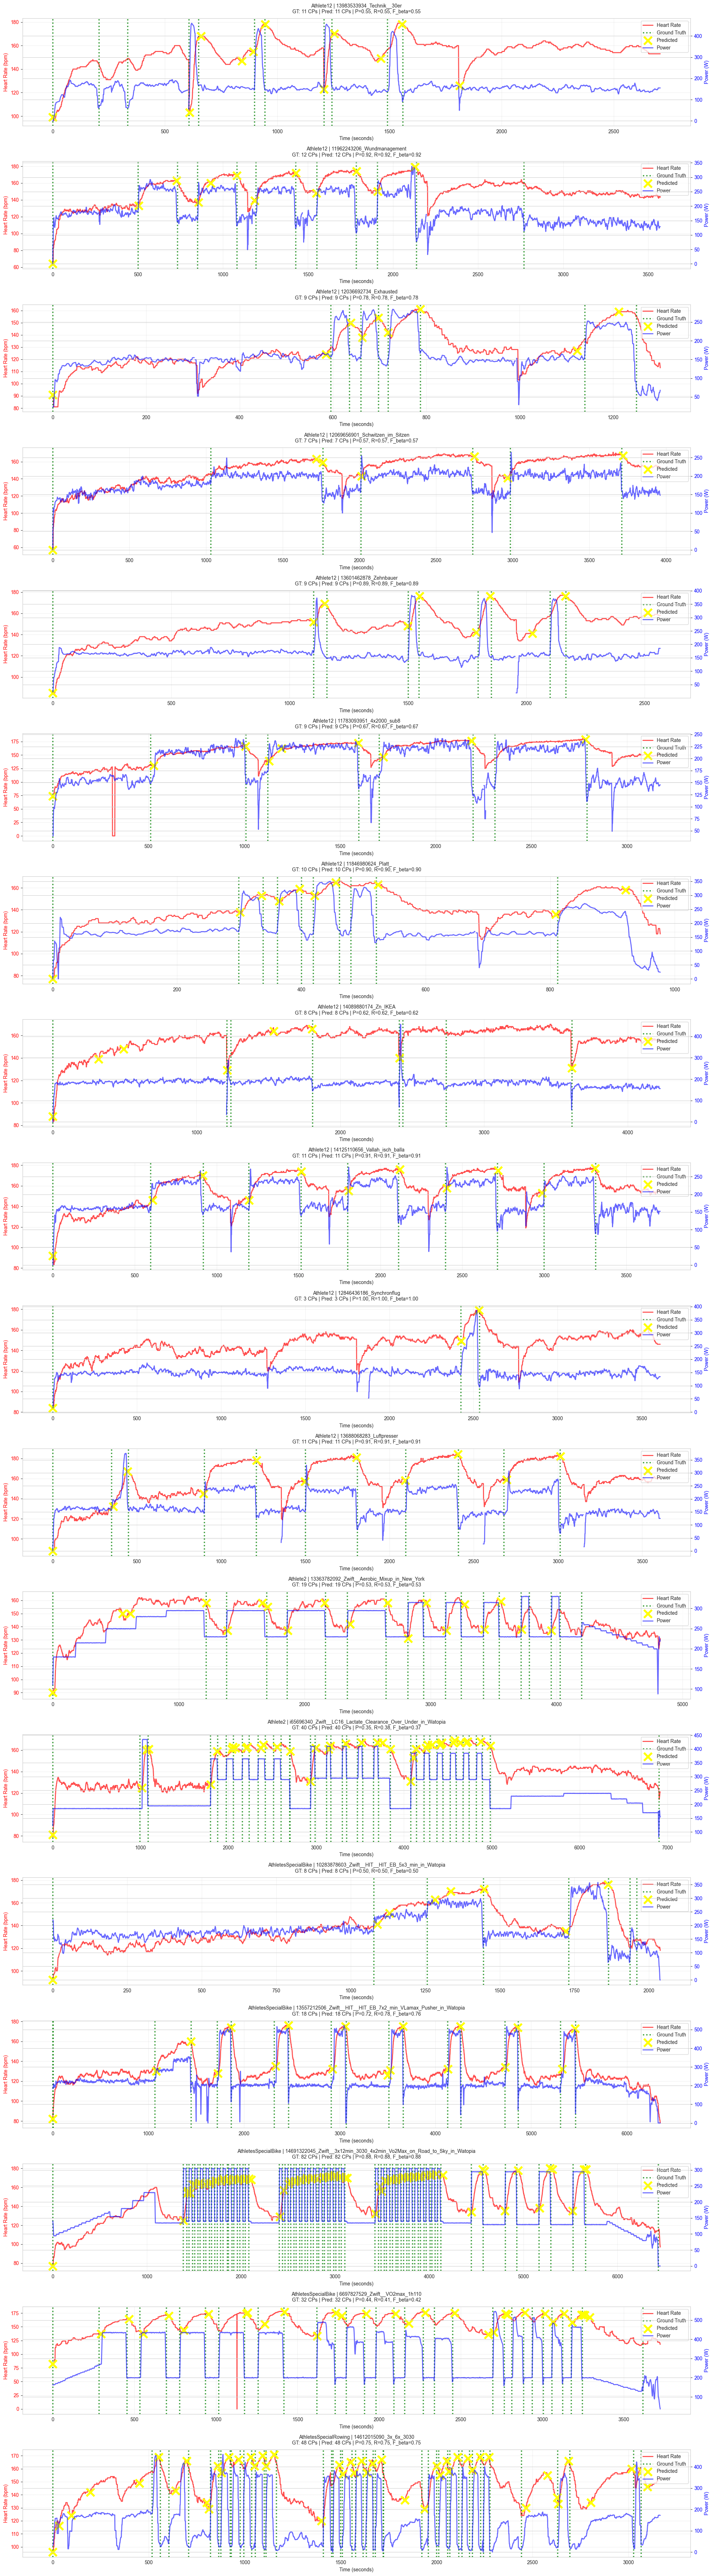

In [48]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical dotted lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with YELLOW X
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Set title with session info and metrics
    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics


✓ Created df_results with 18 test sessions
   Sports breakdown:
     rowing: 12 sessions
     biking: 6 sessions

📊 Preview of df_results:
     athlete                          session   sport  n_intervals    f_beta  \
0  Athlete12        13983533934_Technik__30er  rowing           11  0.545455   
1  Athlete12       11962243206_Wundmanagement  rowing           12  0.916667   
2  Athlete12            12036692734_Exhausted  rowing            9  0.777778   
3  Athlete12  12069656901_Schwitzen_im_Sitzen  rowing            7  0.571429   
4  Athlete12            13601462878_Zehnbauer  rowing            9  0.888889   

   mean_error_sec  
0       33.909091  
1        9.500000  
2        7.777778  
3       12.142857  
4       11.444444  


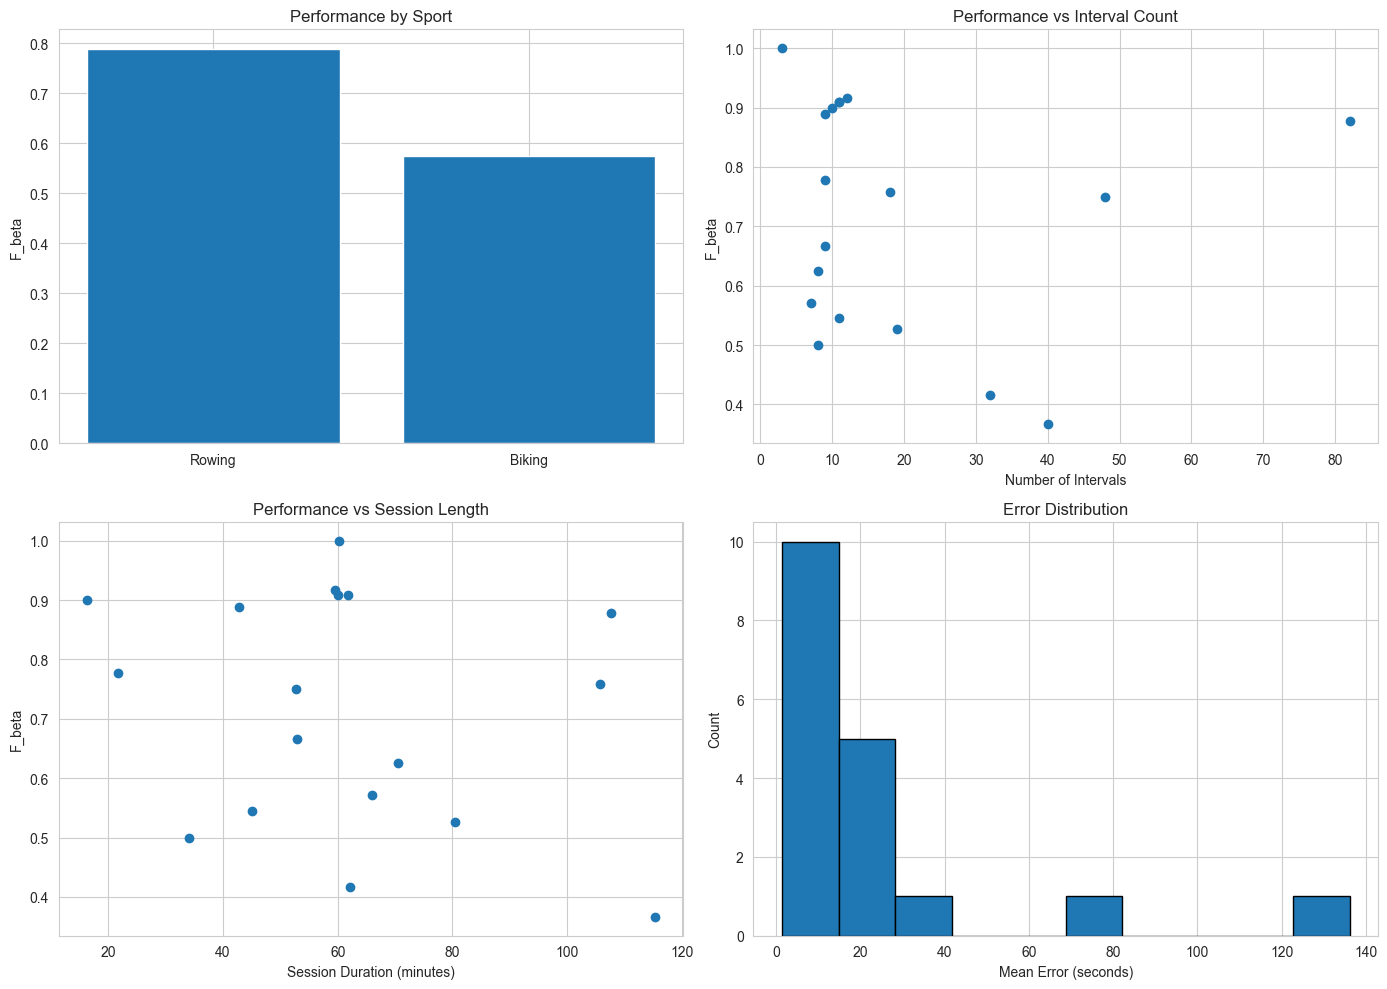

In [49]:
import matplotlib.pyplot as plt
# Create df_results from test_results
import pandas as pd

# Create a mapping from athlete name to sport
athlete_sport_mapping = {
    athlete_name: athlete_data['sport']
    for athlete_name, athlete_data in athletes.items()
}

df_results = pd.DataFrame([
    {
        'athlete': r['athlete'],
        'session': r['session'],
        'n_intervals': r['n_true'],
        'n_pred': r['n_pred'],
        'f_beta': r['f_beta'],
        'precision': r['precision'],
        'recall': r['recall'],
        'mean_error_sec': r['mean_error_sec'],
        'duration_sec': len(r['y_true']),
        'duration_min': len(r['y_true']) / 60,
        'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
    }
    for r in test_results
])

print(f"\n✓ Created df_results with {len(df_results)} test sessions")
print(f"   Sports breakdown:")
for sport, count in df_results['sport'].value_counts().items():
    print(f"     {sport}: {count} sessions")

print(f"\n📊 Preview of df_results:")
print(df_results[['athlete', 'session', 'sport', 'n_intervals', 'f_beta', 'mean_error_sec']].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. F_beta by sport
axes[0, 0].bar(['Rowing', 'Biking'],
               [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
                df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0, 0].set_ylabel('F_beta')
axes[0, 0].set_title('Performance by Sport')

# 2. F_beta vs number of intervals
axes[0, 1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0, 1].set_xlabel('Number of Intervals')
axes[0, 1].set_ylabel('F_beta')
axes[0, 1].set_title('Performance vs Interval Count')

# 3. F_beta vs session duration
axes[1, 0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1, 0].set_xlabel('Session Duration (minutes)')
axes[1, 0].set_ylabel('F_beta')
axes[1, 0].set_title('Performance vs Session Length')

# 4. Error distribution
axes[1, 1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1, 1].set_xlabel('Mean Error (seconds)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Error Distribution')

plt.tight_layout()
plt.show()